# 07 · Model evaluation and statistical comparison

**Question this notebook answers:** *when is "model B is better than model A" a statement we can
act on — promote B to serving, let it choose the next experiments?*

A single number such as "validation RMSE = 0.31" is an **estimate** computed from a finite,
noisy, possibly unrepresentative sample. Evaluation is the discipline of making that estimate
honest (no leakage), meaningful (compared with a baseline), quantified (confidence intervals,
paired tests), and decision-relevant (calibration, slices, thresholds, gates).

| Section | Concept | Repository hook |
|---|---|---|
| 1 | train / validation / test roles, leakage | `data.datasets.train_val_split` (hash split), `training.trainer.Trainer.setup` (normalizer fitted on train only) |
| 2 | baselines | `evaluation.evaluator.evaluate` (mean-predictor baseline) |
| 3 | bootstrap confidence intervals | `evaluation.metrics.bootstrap_ci`, `ray_runtime.tasks.parallel_bootstrap_ci` |
| 4 | paired comparison | `evaluation.comparison.paired_compare` |
| 5 | calibration | `evaluation.metrics.coverage`, `inference.predictor.Predictor.predict_with_uncertainty` |
| 6 | distribution shift | new design regions; active-learning rounds are shifted by construction |
| 7 | slice metrics — an aggregate hides a regression | `evaluation.evaluator._slice_metrics` (per-round slices) |
| 8 | threshold selection | turning a regressor into a go/no-go decision |
| 9 | evaluation gating | `evaluation.evaluator.evaluate`, `check_gates`, `EvaluationResult.write` |

## Conceptual model

We want the **risk** of a model $h$ on the distribution $\mathcal D$ we will actually use it on:

$$R(h) = \mathbb E_{(x,y)\sim\mathcal D}\,\ell(h(x), y), \qquad
  \hat R_n(h) = \frac1n\sum_{i=1}^n \ell(h(x_i), y_i).$$

$\hat R_n$ is unbiased for $R$ **only if** the $n$ evaluation examples were (a) drawn from
$\mathcal D$ and (b) never influenced $h$ — neither through gradient updates, nor through
normalisation statistics, early stopping, hyper-parameter choice, or threshold choice. Every
decision that looks at an example "spends" it. Hence three roles:

```text
         fit parameters          choose hyper-params,          report once,
         (gradients)             thresholds, early stop         decide promotion
rows ──► [ TRAIN ] ───────────► [ VALIDATION ] ─────────────► [ TEST / held-out ]
             ▲                          │                             │
             └── normalizer.fit ────────┘ (must NOT see val/test)     └─ touched once
```

And because $\hat R_n$ is a random variable with standard error $\propto 1/\sqrt n$,
every comparison needs an uncertainty statement.

In [1]:
import os, sys, tempfile, time, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
os.environ.setdefault("RAY_DEDUP_LOGS", "1")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (7.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.3})

# Every artifact this notebook creates lives in a fresh temp dir -- never in the repo's
# data/, artifacts/ or mlflow.db.
WORK = Path(tempfile.mkdtemp(prefix="nb07_"))
T0 = time.perf_counter()
print("workspace:", WORK)

workspace: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb07_gnwo1__b


In [2]:
from scipy.stats import norm

from bci_platform.config import PlatformConfig
from bci_platform.data.datasets import ArrayDataset, records_to_frame, train_val_split
from bci_platform.data.generation import generate_candidate_pool, make_oracle, measure_candidates
from bci_platform.data.schema import feature_columns
from bci_platform.evaluation import (bootstrap_ci, check_gates, coverage, evaluate,
                                       paired_compare, regression_metrics, rmse)
from bci_platform.inference import Predictor
from bci_platform.training import Trainer

cfg = PlatformConfig.for_tests(WORK, **{"data.pool_size": 20_000,
                                        "model.hidden_dims": [64, 64],
                                        "training.epochs": 30})
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
FCOLS = feature_columns(cfg.data.n_features)

rng = np.random.default_rng(0)
perm = rng.permutation(len(pool))

def measured(idx, round_id):
    # run the synthetic experiment on pool rows `idx` (deterministic noise per round)
    recs = measure_candidates(pool.iloc[np.sort(idx)], oracle, round_id=round_id, seed=cfg.seed)
    return records_to_frame(recs)

dev = measured(perm[:3000], round_id=0)        # development data (train + validation)
test = measured(perm[3000:5000], round_id=1)   # held-out test set: never used for any choice
X_test = test[FCOLS].to_numpy()
y_test = test["response"].to_numpy()
z_test = oracle.latent(X_test)                 # hidden latent coordinates (diagnostics only)
print(f"dev={len(dev)} rows, test={len(test)} rows, features={len(FCOLS)}")

dev=3000 rows, test=2000 rows, features=32


In [3]:
def train_model(frame, name, **overrides):
    # Trainer + train_val_split exactly as the pipeline uses them; returns (Predictor, TrainResult)
    c = cfg.with_overrides(**overrides) if overrides else cfg
    tr, va = train_val_split(frame, c.training.val_fraction, c.seed, strategy="hash")
    res = Trainer(c).train(ArrayDataset.from_frame(tr), ArrayDataset.from_frame(va),
                           checkpoint_dir=WORK / "ckpt" / name)
    return Predictor.from_checkpoint(res.checkpoint_path), res

def ridge_fit(frame, cols=FCOLS, lam=1.0):
    # closed-form ridge regression on standardized features -- a strong linear baseline
    X = frame[cols].to_numpy(); y = frame["response"].to_numpy()
    mu, sd = X.mean(0), X.std(0)
    Z = np.c_[np.ones(len(X)), (X - mu) / sd]
    P = lam * np.eye(Z.shape[1]); P[0, 0] = 0
    w = np.linalg.solve(Z.T @ Z + P, Z.T @ y)
    return lambda F: np.c_[np.ones(len(F)), (F[cols].to_numpy() - mu) / sd] @ w

model_A, res_A = train_model(dev.iloc[:600], "A")
print(f"model A: n_train={res_A.n_train} n_val={res_A.n_val} "
      f"val_rmse(std units)={res_A.metrics['val_rmse']:.3f} ({res_A.duration_s:.1f}s)")

model A: n_train=456 n_val=144 val_rmse(std units)=0.399 (0.6s)


## 1 · Splits and leakage

### 1a — The winner's curse: selecting on the test set

Choosing among $K$ models by their score on the *same* set you then report is a minimum over
$K$ noisy estimates, and $\mathbb E[\min_k \hat R_k] < \min_k R_k$. Below: 100 ridge models, each
fitted on a different random 80-row subset (similar true quality), are ranked on a small
"test set #1" (60 rows); we report the winner's score on #1 and on a fresh set #2, averaged
over 50 random choices of #1.

In [4]:
sub_rng = np.random.default_rng(1)
P = np.stack([ridge_fit(dev.iloc[sub_rng.choice(len(dev), 80, replace=False)], lam=5.0)(test)
              for _ in range(100)])                   # (100 models, n_test)
sq_err = (P - y_test) ** 2
res = []
for _ in range(50):
    ii = sub_rng.permutation(len(y_test)); t1, t2 = ii[:60], ii[60:]
    r1, r2 = np.sqrt(sq_err[:, t1].mean(1)), np.sqrt(sq_err[:, t2].mean(1))
    k = r1.argmin()
    res.append({"winner on #1": r1[k], "winner on fresh #2": r2[k],
                "best model on #2": r2.min(), "average model on #2": r2.mean()})
pd.DataFrame(res).mean().to_frame("mean RMSE over 50 repetitions").T

,winner on #1,winner on fresh #2,best model on #2,average model on #2
mean RMSE over 50 repetitions,0.6792,0.8209,0.7559,0.8586


The winner's score on the set used to pick it is optimistic by a wide margin — the selection
consumed that set. This is why hyper-parameters, early stopping and thresholds are chosen on
*validation* data and the test set is touched once.

### 1b — Split stability as rounds are added

The platform adds experimental rounds over time. If the validation split is re-drawn at random
each time, rows the **incumbent** model trained on land in the **new** validation set and the
incumbent looks far better than it is (leakage across model versions). `train_val_split(...,
strategy="hash")` assigns each experiment by `sha256(seed:experiment_id)`, so an experiment's
side never changes:

In [5]:
small, grown = dev.iloc[:500], dev.iloc[:1000]      # "round 0" vs "rounds 0..1"
for strategy in ("hash", "random"):
    _, va_small = train_val_split(small, 0.2, cfg.seed, strategy=strategy)
    tr_grown, _ = train_val_split(grown, 0.2, cfg.seed, strategy=strategy)
    leaked = set(va_small.experiment_id) & set(tr_grown.experiment_id)
    print(f"{strategy:>6}: {len(leaked):3d} of {len(va_small)} old validation rows are now training rows")

  hash:   0 of 118 old validation rows are now training rows
random:  76 of 100 old validation rows are now training rows


Other leakage routes handled in the repository: the `Normalizer` is fitted on the **training
split only** inside `Trainer.setup` (fitting it on all rows leaks validation means/variances);
`evaluate()` uses the *training* target mean as its mean-predictor baseline rather than the
evaluation-set mean. Duplicated experiments (replicates of the same candidate) must be split
**by candidate id**, which the hash split does automatically.

## 2 · Baselines

A metric is only interpretable relative to what a trivial or simple model achieves.

In [6]:
train_mean = dev.iloc[:600]["response"].mean()
preds = {
    "mean predictor": np.full(len(test), train_mean),
    "ridge (linear)": ridge_fit(dev.iloc[:600])(test),
    "ResidualMLP (A)": model_A.predict(test),
}
baselines = pd.DataFrame({k: regression_metrics(y_test, p) for k, p in preds.items()}).T
baselines

,mae,rmse,r2,n
mean predictor,1.5230,1.8964,-0.0008,2000.0
ridge (linear),0.5317,0.6958,0.8653,2000.0
ResidualMLP (A),0.5233,0.6809,0.8710,2000.0


## 3 · Bootstrap confidence intervals

The percentile bootstrap resamples the $n$ evaluation rows with replacement $B$ times and reads
the CI off the empirical distribution of the metric. For RMSE,
$\operatorname{SE}(\widehat{\mathrm{MSE}}) = \sqrt{\operatorname{Var}(e^2)/n}$, so CI width
shrinks like $1/\sqrt n$ — quadrupling the test set halves the interval.

In [7]:
pA = preds["ResidualMLP (A)"]
rows = []
for n in (50, 200, 800, 2000):
    pt, lo, hi = bootstrap_ci(rmse, y_test[:n], pA[:n], n=1000, seed=0)
    rows.append({"n_test": n, "rmse": pt, "ci_lo": lo, "ci_hi": hi, "width": hi - lo,
                 "width*sqrt(n)": (hi - lo) * np.sqrt(n)})
pd.DataFrame(rows)

,n_test,rmse,ci_lo,ci_hi,width,width*sqrt(n)
0,50,0.6854,0.5416,0.8405,0.2989,2.1137
1,200,0.6727,0.6065,0.7444,0.1379,1.9506
2,800,0.6737,0.6353,0.7150,0.0797,2.2531
3,2000,0.6809,0.6559,0.7063,0.0504,2.2532


The resamples are embarrassingly parallel. `ray_runtime.tasks.parallel_bootstrap_ci` puts
`y`/`ŷ` into the Ray object store **once** and fans the resamples out over tasks (each with an
independent `SeedSequence` stream, so the answer is deterministic and a retried task returns
the same numbers):

In [8]:
import ray
from bci_platform.ray_runtime.cluster import ensure_ray
from bci_platform.ray_runtime.tasks import parallel_bootstrap_ci

ensure_ray(num_cpus=4, log_to_driver=False)
print("serial   :", np.round(bootstrap_ci(rmse, y_test, pA, n=2000, seed=0), 4))
print("ray tasks:", np.round(parallel_bootstrap_ci(y_test, pA, n_resamples=2000, n_tasks=4, seed=0), 4))

2026-09-27 08:20:42,840	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


serial   : [0.6809 0.6553 0.707 ]


ray tasks: [0.6809 0.6548 0.7071]


## 4 · Paired comparison

Two models scored on the **same** rows have correlated errors: an example that is hard for A is
usually hard for B. For the per-example loss difference $d_i = \ell^A_i - \ell^B_i$:

$$\operatorname{Var}(\bar\ell^A - \bar\ell^B) = \frac{1}{n}\Big(\sigma_A^2 + \sigma_B^2 - 2\,\operatorname{Cov}(\ell^A,\ell^B)\Big)$$

The covariance term is large and positive, so the *paired* interval on the difference is much
narrower than what you would infer from two overlapping marginal CIs. `paired_compare` resamples
the same indices for both models; `diff = metric(a) - metric(b) > 0` means **b is better**.

Here: incumbent = ridge, candidate = model A, on a deliberately small test set (n = 150).

In [9]:
n = 150
pR = preds["ridge (linear)"]
for name, p in (("ridge", pR), ("model A", pA)):
    pt, lo, hi = bootstrap_ci(rmse, y_test[:n], p[:n], n=1000, seed=0)
    print(f"{name:>8}: RMSE {pt:.3f}  unpaired 95% CI [{lo:.3f}, {hi:.3f}]")
cmp = paired_compare(y_test[:n], pR[:n], pA[:n], metric="rmse", n_boot=1000, seed=0)
print(f"\npaired diff (ridge - A) = {cmp.diff:+.3f}, 95% CI [{cmp.ci_lo:+.3f}, {cmp.ci_hi:+.3f}], "
      f"P(A not better) = {cmp.p_b_not_better:.3f}, A significantly better: {cmp.b_better}")
e_r, e_a = (pR[:n] - y_test[:n]) ** 2, (pA[:n] - y_test[:n]) ** 2
print(f"corr(per-example sq. error ridge, A) = {np.corrcoef(e_r, e_a)[0, 1]:.2f}")

   ridge: RMSE 0.727  unpaired 95% CI [0.630, 0.824]
 model A: RMSE 0.698  unpaired 95% CI [0.616, 0.777]

paired diff (ridge - A) = +0.028, 95% CI [-0.053, +0.103], P(A not better) = 0.253, A significantly better: False
corr(per-example sq. error ridge, A) = 0.61


## 5 · Calibration

A regressor that reports $(\mu, \sigma)$ is **calibrated** if the central $p$-interval
$\mu \pm z_p\sigma$, $z_p = \Phi^{-1}(\tfrac{1+p}{2})$, contains the truth a fraction $p$ of the
time. A reliability plot draws observed coverage against nominal $p$; the diagonal is perfect.

`Predictor.predict_with_uncertainty` returns MC-dropout **epistemic** std by default and adds the
homoscedastic residual estimate in quadrature with `include_aleatoric=True`. Active learning
ranks with the former; interval statements about *measurements* need the latter.

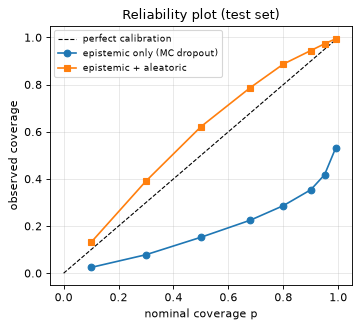

95% coverage: epistemic only = 0.417, total = 0.973


In [10]:
mu_e, sd_epi = model_A.predict_with_uncertainty(test, 30, seed=0)
mu_t, sd_tot = model_A.predict_with_uncertainty(test, 30, seed=0, include_aleatoric=True)
levels = np.array([0.1, 0.3, 0.5, 0.68, 0.8, 0.9, 0.95, 0.99])
zs = norm.ppf(0.5 + levels / 2)
cov_epi = [coverage(y_test, mu_e, sd_epi, z) for z in zs]
cov_tot = [coverage(y_test, mu_t, sd_tot, z) for z in zs]

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.plot(levels, cov_epi, "o-", label="epistemic only (MC dropout)")
ax.plot(levels, cov_tot, "s-", label="epistemic + aleatoric")
ax.set(xlabel="nominal coverage p", ylabel="observed coverage", title="Reliability plot (test set)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"95% coverage: epistemic only = {cov_epi[6]:.3f}, total = {cov_tot[6]:.3f}")

## 6 · Distribution shift

Deployment data rarely matches the training distribution (**covariate shift**): a new region of
design space is opened up, active learning moves toward the tail, an instrument is replaced.
Below, the "shifted" candidates are drawn from a wider design distribution
($x \sim \mathcal N(0, 1.7^2)$ clipped to the feasible box, instead of $\mathcal N(0, 1)$) and
measured by the same oracle. Errors and calibration measured on in-distribution data do not
transfer — and MC-dropout uncertainty does **not** reliably flag the problem.

In [11]:
shift_rng = np.random.default_rng(5)
X_shift = np.clip(1.7 * shift_rng.standard_normal((2000, len(FCOLS))), -3, 3)
y_shift, _ = oracle.measure(X_shift, shift_rng)
shift_frame = pd.DataFrame(X_shift, columns=FCOLS)
mu_s, sd_s = model_A.predict_with_uncertainty(shift_frame, 30, seed=0, include_aleatoric=True)
_, sde_s = model_A.predict_with_uncertainty(shift_frame, 30, seed=0)
pd.DataFrame([
    {"eval set": "in-distribution test", "rmse": rmse(y_test, mu_t),
     "coverage_95": coverage(y_test, mu_t, sd_tot, 1.96), "mean_epistemic_std": sd_epi.mean()},
    {"eval set": "shifted (wider design)", "rmse": rmse(y_shift, mu_s),
     "coverage_95": coverage(y_shift, mu_s, sd_s, 1.96), "mean_epistemic_std": sde_s.mean()},
]).set_index("eval set")

,rmse,coverage_95,mean_epistemic_std
eval set,,,
in-distribution test,0.6733,0.9730,0.1744
shifted (wider design),1.3249,0.7935,0.1359


RMSE roughly doubles and the nominal 95 % intervals under-cover, yet the average epistemic std
does not increase: MC dropout on a small MLP is a *weak* out-of-distribution detector. Monitor
input distributions directly (feature ranges, distance to the training set, a domain
classifier) and evaluate prospectively on each new round.

## 7 · Slice metrics: an aggregate metric can conceal a regression

**Scenario.** A new data source doubles the training set, but its instrument **saturates**: every
response above the 85th percentile is recorded at the saturation value. Model B is trained on the
new instrument's 2 400 rows (four times more data than A's 600 clean rows). Its own
*validation* RMSE looks great — the validation rows are clipped too.

Overall, B beats A on the clean test set. On the slice the program actually cares about —
the high-response region where the next experiments will be chosen — B is much worse.

In [12]:
sat = np.quantile(dev["response"], 0.85)
clipped = dev.iloc[600:3000].copy()
clipped["response"] = np.minimum(clipped["response"], sat)
model_B, res_B = train_model(clipped, "B")
pB = model_B.predict(test)
print(f"validation RMSE (std units, on its own split): A={res_A.metrics['val_rmse']:.3f}  "
      f"B={res_B.metrics['val_rmse']:.3f}")

tail = z_test[:, 0] > 1.3        # high-response region (large latent z0, the oracle's tall bump)
slices = {"all": np.ones(len(test), bool),
          "z0 <= 1.3": ~tail,
          "z0 > 1.3 (high-response region)": tail}
rows = []
for name, m in slices.items():
    c = paired_compare(y_test[m], pA[m], pB[m], metric="rmse", n_boot=1000, seed=0)
    rows.append({"slice": name, "n": c.n, "rmse_A": c.a_value, "rmse_B": c.b_value,
                 "diff (A-B)": c.diff, "ci_lo": c.ci_lo, "ci_hi": c.ci_hi,
                 "verdict": "B better" if c.b_better else ("A better" if c.a_better else "n.s.")})
slice_table = pd.DataFrame(rows).set_index("slice")
slice_table

validation RMSE (std units, on its own split): A=0.399  B=0.307


,n,rmse_A,rmse_B,diff (A-B),ci_lo,ci_hi,verdict
slice,,,,,,,
all,2000,0.6809,0.6398,0.0411,0.0108,0.0700,B better
z0 <= 1.3,1791,0.6776,0.5627,0.1149,0.0881,0.1418,B better
z0 > 1.3 (high-response region),209,0.7079,1.0970,-0.3891,-0.4893,-0.2736,A better


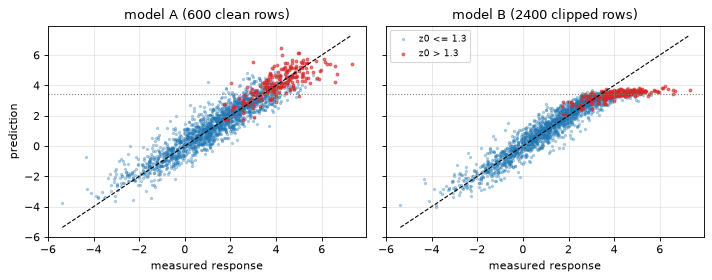

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, p, name in ((axes[0], pA, "model A (600 clean rows)"), (axes[1], pB, "model B (2400 clipped rows)")):
    ax.scatter(y_test[~tail], p[~tail], s=4, alpha=0.3, label="z0 <= 1.3")
    ax.scatter(y_test[tail], p[tail], s=6, alpha=0.6, c="C3", label="z0 > 1.3")
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, "k--", lw=1); ax.axhline(sat, color="gray", ls=":", lw=1)
    ax.set(title=name, xlabel="measured response")
axes[0].set_ylabel("prediction"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Pre-register slices (by round, by region/assay/instrument, by predicted-value decile) *before*
looking at results, and gate on the worst important slice, not only on the average. The
repository's `evaluate()` reports per-`round_id` slices (`EvaluationResult.slices`); adding a
region slice gate is the exercise at the end.

## 8 · Threshold selection

A regressor becomes a decision when we threshold it: *run the experiment if* $\hat y > t$.
Suppose a "hit" is a measured response in the top 10 % of the development data. The threshold
is a hyper-parameter: choose it on **validation** rows (never on test), then report test
precision/recall once.

threshold chosen on validation (max F1): t* = 3.68
test: precision=0.61 recall=0.83 F1=0.70 (base rate of hits = 0.10)


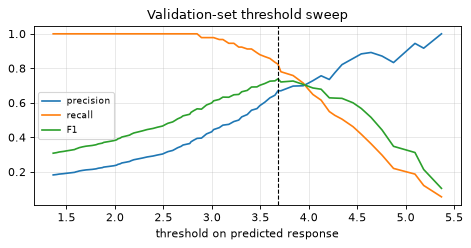

In [14]:
hit_level = np.quantile(dev["response"], 0.90)
val_rows = dev.iloc[600:1600]                       # not used to train model A
yv, pv = val_rows["response"].to_numpy(), model_A.predict(val_rows)

def prf(y, p, t):
    pred_hit, true_hit = p > t, y > hit_level
    tp = np.sum(pred_hit & true_hit)
    prec = tp / max(pred_hit.sum(), 1); rec = tp / max(true_hit.sum(), 1)
    return prec, rec, 2 * prec * rec / max(prec + rec, 1e-12)

ts = np.quantile(pv, np.linspace(0.5, 0.995, 80))
curve = np.array([prf(yv, pv, t) for t in ts])
t_star = ts[np.argmax(curve[:, 2])]
p_te, r_te, f_te = prf(y_test, pA, t_star)
print(f"threshold chosen on validation (max F1): t* = {t_star:.2f}")
print(f"test: precision={p_te:.2f} recall={r_te:.2f} F1={f_te:.2f} "
      f"(base rate of hits = {np.mean(y_test > hit_level):.2f})")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(ts, curve[:, 0], label="precision"); ax.plot(ts, curve[:, 1], label="recall")
ax.plot(ts, curve[:, 2], label="F1"); ax.axvline(t_star, color="k", ls="--", lw=1)
ax.set(xlabel="threshold on predicted response", title="Validation-set threshold sweep")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In a lab the right objective is rarely F1: it is usually *expected value per experiment* under a
budget (cost of a false positive = one wasted experiment; cost of a false negative = a missed
discovery). Active learning (notebook 09) replaces the fixed threshold with a ranking under a
batch budget.

## 9 · Evaluation gating in the repository

`evaluate(predictor, eval_frame, baseline_predictions, cfg, target_scale=...)` computes metrics in
standardized units, a bootstrap CI for RMSE, a paired comparison
against the baseline, MC-dropout NLL/coverage, per-round slices, and a `GateDecision` from
`check_gates`:

```yaml
evaluation:
  max_rmse: 0.35                     # absolute quality bar (standardized RMSE)
  min_improvement_vs_baseline: 0.02  # relative RMSE improvement vs incumbent / mean predictor
```

A model that fails stays available for research but is not promoted (`tracking.registry.ModelRegistry.promote_if_passed`).

**Whose standard deviation?** "Standardized" needs a yardstick, and it must belong to the
*evaluation data*, not to the candidate: if each candidate were standardized with its own training
statistics, B (whose clipped targets have a smaller std) would be judged on a different scale than
A, and `max_rmse` would mean something different for every candidate. The pipeline therefore
passes a `TargetScale` built from the training split of the round's dataset, identical for the
candidate and the baseline, and records it in `metrics.json` (`standardization`) and `report.md`.
Here the yardstick is the clean development data.

In [15]:
# Candidate B vs incumbent A, both scored on the clean test set, in the units of ONE dataset-owned
# scale (the clean development data) -- not B's own (clipped, narrower) training statistics.
from bci_platform.evaluation import TargetScale

scale = TargetScale.from_targets(dev["response"], source="clean development data (rows 0-2999)")
gate_cfg = cfg
result = evaluate(model_B, test, baseline_predictions=pA, cfg=gate_cfg,
                  baseline_name="incumbent model A", target_scale=scale)
print("standardization:", result.target_scale)
print("gate passed:", result.gate.passed)
for r in result.gate.reasons:
    print("  -", r)
print({k: round(v, 4) for k, v in result.metrics.items()
       if k in ("rmse", "rmse_ci_lo", "rmse_ci_hi", "improvement_vs_baseline", "coverage_95", "nll")})
paths = result.write(WORK / "eval_B_vs_A")
print("artifacts:", sorted(p.name for p in paths.values()))

standardization: {'y_mean': 1.4424147609042592, 'y_std': 1.8964922261944412, 'source': 'clean development data (rows 0-2999)', 'n': 3000}
gate passed: True
  - PASS: standardized RMSE 0.3373 <= max_rmse 0.35
  - PASS: relative RMSE improvement vs incumbent model A +6.04% >= 2.00%
{'rmse': 0.3373, 'rmse_ci_lo': 0.3222, 'rmse_ci_hi': 0.3529, 'nll': 0.3991, 'coverage_95': 0.899, 'improvement_vs_baseline': 0.0604}


artifacts: ['comparison.json', 'metrics.json', 'predictions.parquet', 'report.md']


The **gate passes** — even though section 7 showed B is badly worse on the high-response region.
The gate is only as good as the questions it asks. `check_gates` is a small pure function, so
adding a slice gate is straightforward:

In [16]:
# A hand-rolled slice gate built from the same primitives (paired_compare + check_gates).
ecfg = gate_cfg.evaluation
region = paired_compare(y_test[tail], pA[tail], pB[tail], n_boot=1000, seed=0)
overall = check_gates(result.metrics["rmse"], result.metrics["improvement_vs_baseline"], ecfg,
                      "incumbent model A")
slice_ok = region.relative_improvement >= -0.05          # tolerate at most a 5% slice regression
print(f"overall gate: {overall.passed};  high-response slice: rel. improvement "
      f"{region.relative_improvement:+.1%} -> slice gate {'PASS' if slice_ok else 'FAIL'}")
print("promote B:", overall.passed and slice_ok)

overall gate: True;  high-response slice: rel. improvement -55.0% -> slice gate FAIL
promote B: False


## Connection to this repository

| Concept | Where |
|---|---|
| stable, leakage-free validation split across rounds | `src/bci_platform/data/datasets.py` → `train_val_split(strategy="hash")`; `"newest_round"` for prospective checks |
| normaliser fitted on training rows only | `src/bci_platform/training/trainer.py` → `Trainer.setup` (`Normalizer.fit(train_ds.X, train_ds.y)`) |
| metrics + bootstrap CI | `src/bci_platform/evaluation/metrics.py` → `rmse`, `coverage`, `nll_gaussian`, `bootstrap_ci` |
| paired bootstrap | `src/bci_platform/evaluation/comparison.py` → `paired_compare`, `ComparisonResult.b_better` |
| gates + report artifacts | `src/bci_platform/evaluation/evaluator.py` → `evaluate`, `check_gates`; `reporting.py` → `write_evaluation` (`metrics.json`, `report.md`, `predictions.parquet`, `comparison.json`) |
| parallel resampling | `src/bci_platform/ray_runtime/tasks.py` → `parallel_bootstrap_ci` |
| promotion only after the gate | `src/bci_platform/tracking/registry.py` → `ModelRegistry.promote_if_passed` |

## Failure modes

* **Test-set reuse** — every look at the test set to make a decision turns it into validation data
  (winner's curse, §1a). Keep a truly held-out set, or a *prospective* one (the next round).
* **Split instability across versions** — re-randomised splits leak incumbent training rows into
  the new validation set (§1b).
* **Unpaired comparisons** — overlapping marginal CIs are *not* evidence of "no difference" (§4).
* **Aggregate-only gates** — an improvement on the average can hide a severe regression on the
  slice that matters (§7, §9). Also: label corruption shared by train and validation is invisible
  to validation metrics.
* **Uncalibrated uncertainty** — epistemic-only intervals under-cover measured responses (§5);
  all intervals degrade under shift (§6).
* **Evaluation under selection bias** — rows chosen by active learning are not a random sample;
  do not average them with random rows and call it "generalisation error".

## Exercise

1. Add a **slice gate** to the evaluation: extend a copy of `check_gates` with a
   `max_slice_regression` threshold evaluated on region slices (e.g. deciles of predicted mean),
   and show that it rejects model B but accepts a model trained on 2 400 *unclipped* rows.
2. Repeat §4 with `metric="mae"`. Is the paired verdict the same? Why can RMSE and MAE disagree?
3. Re-do §8 with an economic objective: a hit is worth 10 units, every experiment costs 1 unit.
   Which threshold maximises expected profit on validation, and what does it earn on test?

In [17]:
ray.shutdown()
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print(f"done in {time.perf_counter() - T0:.1f}s; Ray shut down, workspace removed")

done in 13.7s; Ray shut down, workspace removed
